<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/teste1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 11.3 MB/s eta 0:00:00


EXEMPLO 1: INFERÊNCIA COCO E VALIDAÇÃO DE CONFIANÇA
-> Analisando a imagem: xicara.png

[RELATÓRIO DE VALIDAÇÃO COCO]
Total de instâncias de 'cup' encontradas: 1
  -> Objeto 1:
     * Coordenadas (Pascal VOC): [170, 224, 556, 503]
     * Grau de Certeza (Confidence): 81.19%
     * Veredito: ALTA CONFIABILIDADE


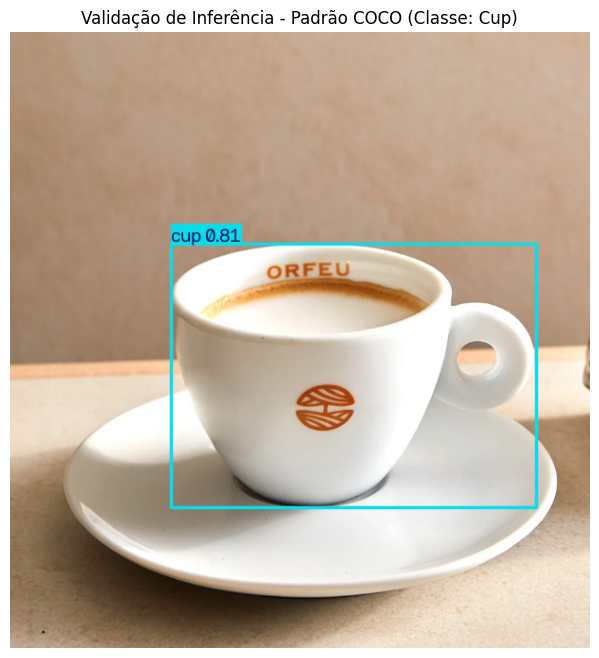

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("="*80)
print("EXEMPLO 1: INFERÊNCIA COCO E VALIDAÇÃO DE CONFIANÇA")
print("="*80)

# 1. Carregando o modelo base universal (80 classes)
modelo_coco = YOLO('yolov8n.pt')

# 2. Defina aqui o caminho da imagem que você vai subir no Colab (ex: 'minha_xicara.jpg')
# Objeto-alvo escolhido do COCO para o seu teste: 'cup' (ID 41)
caminho_sua_imagem = 'xicara.png'

print(f"-> Analisando a imagem: {caminho_sua_imagem}")

# 3. Executando a predição focando na classe 'cup' (ID 41 no COCO)
resultados = modelo_coco.predict(
    source=caminho_sua_imagem,
    conf=0.40,      # Limiar mínimo de certeza aceitável
    classes=[41],   # Filtro estrito: apenas xícaras/copos
    verbose=False
)

resultado = resultados[0]
caixas = resultado.boxes

print(f"\n[RELATÓRIO DE VALIDAÇÃO COCO]")
print(f"Total de instâncias de 'cup' encontradas: {len(caixas)}")

# 4. Validando os tensores e métricas individuais
for i, box in enumerate(caixas):
    conf = box.conf[0].item()
    coords = box.xyxy[0].cpu().numpy().astype(int)

    # Validação de qualidade industrial baseada na certeza da IA
    status_qualidade = "ALTA CONFIABILIDADE" if conf >= 0.80 else "ZONA DE ATENÇÃO (Revisar)"

    print(f"  -> Objeto {i+1}:")
    print(f"     * Coordenadas (Pascal VOC): {coords.tolist()}")
    print(f"     * Grau de Certeza (Confidence): {conf*100:.2f}%")
    print(f"     * Veredito: {status_qualidade}")

# 5. Renderização gráfica final
img_plotada = cv2.cvtColor(resultado.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_plotada)
plt.title("Validação de Inferência - Padrão COCO (Classe: Cup)")
plt.axis('off')
plt.show()